In [22]:
import json
import os

import pandas as pd

# Plot the accuracy

# WITHOUT BEAM MATCHING
dir = '../data/results/experiments/beam_matching_experiment_6'
data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

config

{'wknn_k': 2,
 'rf_param': 'rsrq',
 'operator_choice': [10],
 'n_runs': 40,
 'campaigns': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60],
 'runtime': 1089.8764481544495}

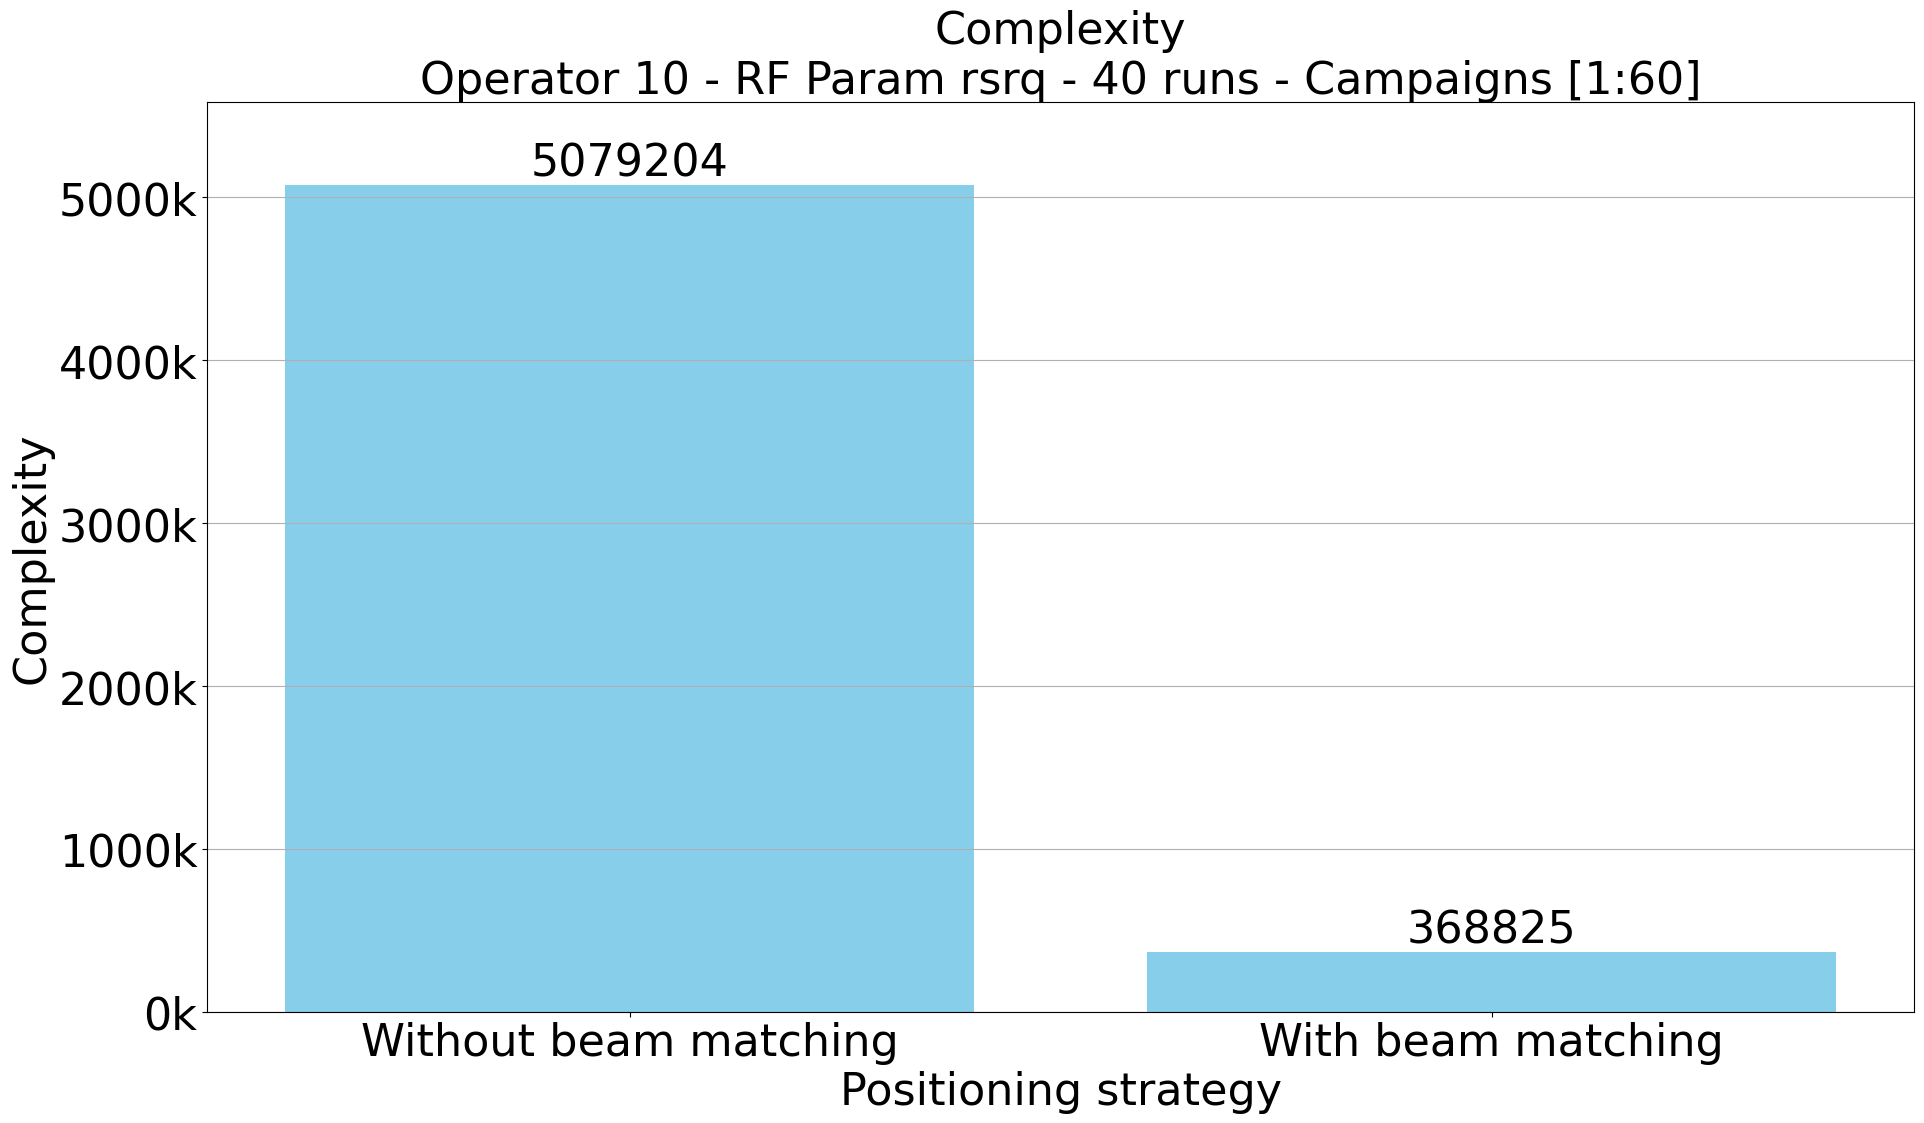

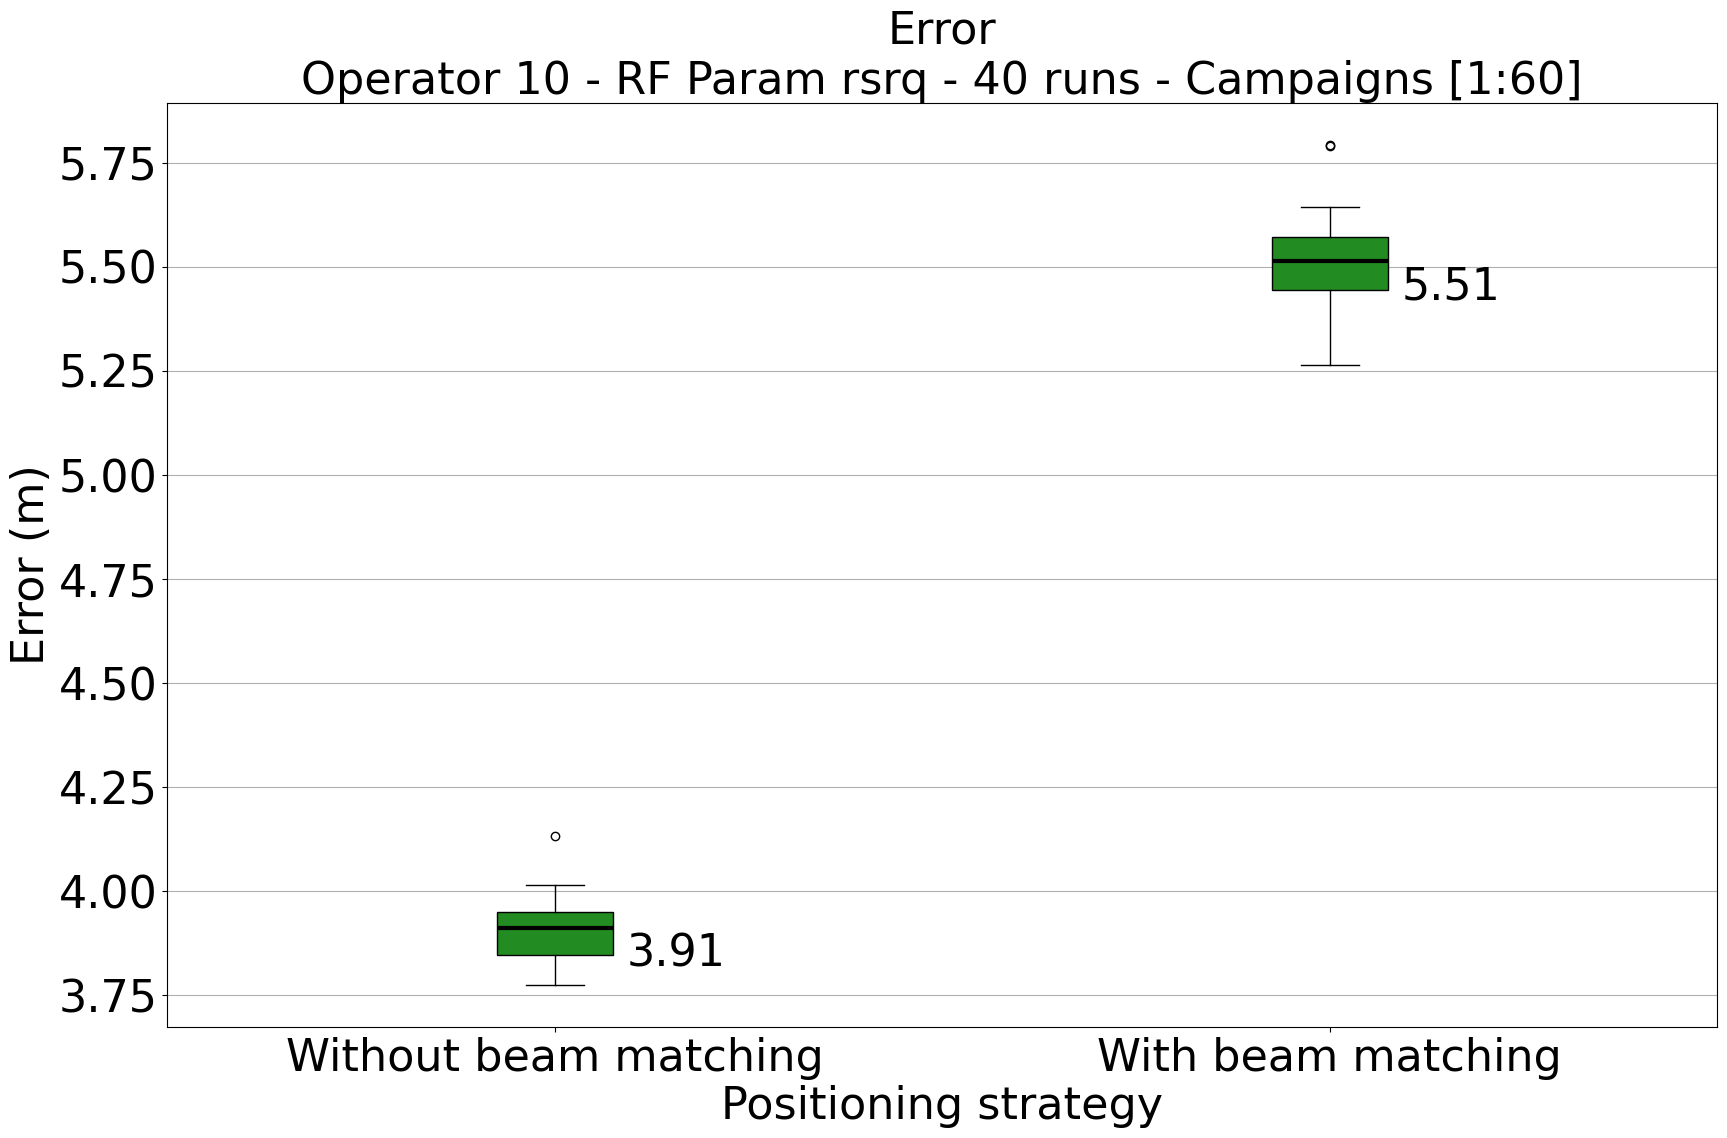

,Without beam matching,With beam matching
0,3.805532,5.419051
1,3.945443,5.643433
2,4.133142,5.603786
3,3.941119,5.496854
4,3.797114,5.510890
5,3.919830,5.569330
6,4.016162,5.512642
7,3.839691,5.334849
8,4.006458,5.590172
9,3.922471,5.531992


In [36]:
from scripts.plotting import *

title = f"Operator {config['operator_choice'][0]} - RF Param {config['rf_param']} - {config['n_runs']} runs - Campaigns [{config['campaigns'][0]}:{config['campaigns'][-1]}]"

errors_df = data_df[['errors_control', 'errors']].copy()
complexity_df = data_df[['complexity_control', 'complexity']].copy()

errors_df.rename(columns={
    'errors': 'With beam matching',
    'errors_control': 'Without beam matching',
}, inplace=True)

complexity_df.rename(columns={
    'complexity': 'With beam matching',
    'complexity_control': 'Without beam matching',
}, inplace=True)

make_barplot(
    df=complexity_df,
    x_label="Positioning strategy",
    y_label="Complexity",
    title=f"Complexity\n{title}",
    annotate=True
)

make_boxplot(
    df=errors_df,
    x_label="Positioning strategy",
    y_label="Error (m)",
    title=f"Error\n{title}",
    annotate=True
)

errors_df

In [45]:
com = complexity_df.mean().to_numpy()

old, new = com[0], com[1]

res = (new - old) / old * 100

res

np.float64(-92.73853082374592)